In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_openai import ChatOpenAI
from typing import TypedDict, Annotated


In [2]:
from dotenv import load_dotenv
load_dotenv()  

True

In [3]:
endpoint = "https://models.github.ai/inference"
llm = ChatOpenAI(base_url=endpoint,model_name = "openai/gpt-4o-mini")

In [4]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [5]:
def chat_node(state: ChatState):
    messages = state['messages']
    response = llm.invoke(messages)
    return {'messages': [response]}

In [9]:
graph = StateGraph(ChatState)

In [10]:
graph.add_node('chat_node', chat_node)

graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

In [12]:
chatbot = graph.compile()

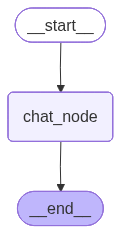

In [13]:
chatbot

In [20]:
initial_state = {
    "messages" : [HumanMessage(content="What is the meaning of life?")]
}

chatbot.invoke(initial_state)["messages"][-1].content

'The meaning of life is a philosophical question that has been contemplated for centuries and can vary greatly depending on individual beliefs, cultures, and experiences. Some common perspectives include:\n\n1. **Religious/Spiritual View**: Many religions suggest that the meaning of life is to fulfill a divine purpose, connect with a higher power, or achieve spiritual enlightenment.\n\n2. **Philosophical View**: Various philosophical schools offer different interpretations. Existentialism, for example, posits that individuals create their own meaning through choices and actions, while nihilism suggests that life lacks inherent meaning.\n\n3. **Personal Purpose**: For many, meaning is derived from personal fulfillment, relationships, contributions to society, and the pursuit of happiness or knowledge.\n\n4. **Biological Perspective**: From a scientific standpoint, the meaning of life can be viewed in terms of survival, reproduction, and the continuation of species.\n\nUltimately, the me

In [ ]:
while True:
    input_msg = input("> ")

    if input_msg in ["q"]:
        break
    initial_state = {
        "messages" : [HumanMessage(content=input_msg)]
    }
    response = chatbot.invoke(initial_state)["messages"][-1].content
    print(": ", response)

In [22]:
initial_state = {
    "messages" : [HumanMessage(content="What is the meaning of life?")]
}

while True:
    input_msg = input("> ")

    if input_msg in ["q"]:
        break
    response = chatbot.invoke(initial_state)["messages"][-1].content
    print(": ", response)

>  what is your opinion


:  The meaning of life is a profound and philosophical question that has been contemplated by thinkers, theologians, and individuals throughout history. Different cultures and belief systems offer various interpretations:

1. **Philosophical Views**: Some philosophers argue that meaning is subjective and that individuals must create their own purpose through experiences, relationships, and contributions to society.

2. **Religious Perspectives**: Many religions provide frameworks for understanding life's purpose, often suggesting that it involves a relationship with a higher power, adherence to moral principles, and the pursuit of spiritual growth.

3. **Scientific Approaches**: From a scientific standpoint, the meaning of life can be seen in terms of survival, reproduction, and the continuation of species, with a focus on understanding the universe and our place within it.

4. **Existential Views**: Existentialists contend that life has no inherent meaning, and it is up to each person

>  what was my question


:  The question of the meaning of life is a profound and philosophical one that has been explored across cultures and centuries. Different perspectives offer various interpretations:

1. **Philosophical**: Many philosophers, such as existentialists, argue that life has no intrinsic meaning and that individuals must create their own purpose through choices and actions. Others, like utilitarians, suggest that the meaning of life is to maximize happiness and reduce suffering.

2. **Religious**: Various religious traditions propose that life has meaning derived from a higher power or divine purpose. For example, in many religions, the meaning of life involves following spiritual laws, seeking enlightenment, or preparing for an afterlife.

3. **Scientific**: From a scientific perspective, life can be seen as a complex process driven by evolution and survival. In this view, the meaning of life might focus on the continuation of the species and the pursuit of knowledge.

4. **Personal**: Many

>  q


In [23]:
from langgraph.checkpoint.memory import MemorySaver

In [24]:
checkpoint = MemorySaver()
graph = StateGraph(ChatState)
graph.add_node('chat_node', chat_node)

graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)
chatbot = graph.compile(checkpointer=checkpoint)

In [26]:
thread = "1"
while True:
    input_msg = input("> ")

    if input_msg in ["q"]:
        break
    initial_state = {
        "messages" : [HumanMessage(content=input_msg)]
    }
    config = {
        "configurable":{"thread_id": thread}
    }
    response = chatbot.invoke(initial_state, config)["messages"][-1].content
    print(": ", response)

>  I'm thiwa


:  Hello, Thiwa! How can I assist you today?


>  what is my name


:  Your name is Thiwa! How can I help you today?


>  q


In [27]:
thread = "1"
while True:
    input_msg = input("> ")

    if input_msg in ["q"]:
        break
    initial_state = {
        "messages" : [HumanMessage(content=input_msg)]
    }
    config = {
        "configurable":{"thread_id": thread}
    }
    response = chatbot.invoke(initial_state, config)["messages"][-1].content
    print(": ", response)

>  what is my name


:  Your name is Thiwa. If you have any other questions or need assistance, feel free to ask!


>  q


In [29]:
chatbot.get_state(config)

StateSnapshot(values={'messages': [HumanMessage(content="I'm thiwa", additional_kwargs={}, response_metadata={}, id='59a002a1-ef29-4af6-ada9-2851f32d7908'), AIMessage(content='Hello, Thiwa! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 13, 'prompt_tokens': 10, 'total_tokens': 23, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}, 'latency_checkpoint': {'engine_tbt_ms': 9, 'engine_ttft_ms': 26, 'engine_ttlt_ms': 142, 'pre_inference_ms': 83, 'service_tbt_ms': 9, 'service_ttft_ms': 1038, 'service_ttlt_ms': 1145, 'total_duration_ms': 1070, 'user_visible_ttft_ms': 955}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_965c8b9ecf', 'id': 'chatcmpl-DuGhvfaB5CKfg96rF82dPtb8w8EzQ', 'service_tier': 'default', 'finish_reason

In [6]:
from langgraph.checkpoint.memory import InMemorySaver

In [7]:
checkpointer = InMemorySaver()
graph = StateGraph(ChatState)
graph.add_node('chat_node', chat_node)

graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)
chatbot = graph.compile(checkpointer=checkpointer)

In [8]:
thread = "1"
while True:
    input_msg = input("> ")

    if input_msg in ["q"]:
        break
    initial_state = {
        "messages" : [HumanMessage(content=input_msg)]
    }
    config = {
        "configurable":{"thread_id": thread}
    }
    response = chatbot.invoke(initial_state, config)["messages"][-1].content
    print(": ", response)

>  hey boo


:  Hey! How’s it going?


>  what previously I said


:  You just greeted me with "hey boo." What would you like to chat about?


>  q


In [9]:
config = {
        "configurable":{"thread_id": thread}
    }
chatbot.get_state(config)

StateSnapshot(values={'messages': [HumanMessage(content='hey boo', additional_kwargs={}, response_metadata={}, id='fe54d230-d165-45fa-8e6b-50ee27589b0c'), AIMessage(content='Hey! How’s it going?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 8, 'prompt_tokens': 9, 'total_tokens': 17, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}, 'latency_checkpoint': {'engine_tbt_ms': 18, 'engine_ttft_ms': 30, 'engine_ttlt_ms': 178, 'pre_inference_ms': 187, 'service_tbt_ms': 19, 'service_ttft_ms': 818, 'service_ttlt_ms': 958, 'total_duration_ms': 785, 'user_visible_ttft_ms': 631}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_4dcfea0a44', 'id': 'chatcmpl-DuJp83ATx86KevFNWftbGqH0u6RXD', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': No

In [11]:
list(chatbot.get_state_history(config))

[StateSnapshot(values={'messages': [HumanMessage(content='hey boo', additional_kwargs={}, response_metadata={}, id='fe54d230-d165-45fa-8e6b-50ee27589b0c'), AIMessage(content='Hey! How’s it going?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 8, 'prompt_tokens': 9, 'total_tokens': 17, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}, 'latency_checkpoint': {'engine_tbt_ms': 18, 'engine_ttft_ms': 30, 'engine_ttlt_ms': 178, 'pre_inference_ms': 187, 'service_tbt_ms': 19, 'service_ttft_ms': 818, 'service_ttlt_ms': 958, 'total_duration_ms': 785, 'user_visible_ttft_ms': 631}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_4dcfea0a44', 'id': 'chatcmpl-DuJp83ATx86KevFNWftbGqH0u6RXD', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': N

In [15]:


config = {
        "configurable":{"thread_id": thread},
        'checkpoint_id': '1f16fe16-c9b2-655c-bfff-9133b471c037'
    }
chatbot.get_state(config)

StateSnapshot(values={'messages': [HumanMessage(content='hey boo', additional_kwargs={}, response_metadata={}, id='fe54d230-d165-45fa-8e6b-50ee27589b0c'), AIMessage(content='Hey! How’s it going?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 8, 'prompt_tokens': 9, 'total_tokens': 17, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}, 'latency_checkpoint': {'engine_tbt_ms': 18, 'engine_ttft_ms': 30, 'engine_ttlt_ms': 178, 'pre_inference_ms': 187, 'service_tbt_ms': 19, 'service_ttft_ms': 818, 'service_ttlt_ms': 958, 'total_duration_ms': 785, 'user_visible_ttft_ms': 631}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_4dcfea0a44', 'id': 'chatcmpl-DuJp83ATx86KevFNWftbGqH0u6RXD', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': No

In [16]:
list(chatbot.get_state_history(config))

[StateSnapshot(values={'messages': []}, next=('__start__',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f16fe16-c9b2-655c-bfff-9133b471c037'}}, metadata={'source': 'input', 'step': -1, 'parents': {}}, created_at='2026-06-24T15:29:00.562773+00:00', parent_config=None, tasks=(PregelTask(id='74267aa4-70fd-55e0-c5b0-fabf65bf07ab', name='__start__', path=('__pregel_pull', '__start__'), error=None, interrupts=(), state=None, result={'messages': [HumanMessage(content='hey boo', additional_kwargs={}, response_metadata={}, id='fe54d230-d165-45fa-8e6b-50ee27589b0c')]}),), interrupts=())]